监督学习算法

线性回归（Linear Regression）：用于回归任务，预测连续的数值。  
逻辑回归（Logistic Regression）：用于二分类任务，预测类别。  
支持向量机（SVM）：用于分类任务，构建超平面进行分类。  
决策树（Decision Tree）：基于树状结构进行决策的分类或回归方法。  

In [65]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline
import warnings
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing 
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error
from sklearn import svm, datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor


# 全局字体设置：自动选择系统中可用的中文字体，避免中文标题显示为方块
candidate_fonts = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans CN', 'Arial Unicode MS']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in candidate_fonts if f in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['axes.unicode_minus'] = False

线性回归 (Linear Regression) 
1. 核心概念 
线性回归（Linear Regression）是机器学习中最基础且广泛应用的算法之一。  
线性回归 (Linear Regression) 是一种用于预测连续值的最基本的机器学习算法，它假设目标变量 y 和特征变量 x 之间存在线性关系，并试图找到一条最佳拟合直线来描述这种关系。  
y = w * x + b  
其中：  
y 是预测值  
x 是特征变量  
w 是权重 (斜率)  
b 是偏置 (截距)  
2. 目标
线性回归的目标是找到最佳的 w 和 b，使得预测值 y 与真实值之间的误差最小。常用的误差函数是均方误差 (MSE)： 
MSE = 1/n * Σ(y_i - y_pred_i)^2  
其中：  
y_i 是实际值。  
y_pred_i 是预测值。  
n 是数据点的数量。  
我们的目标是通过调整 w 和 b ，使得 MSE 最小化。  

斜率 (w): 2.968467510701018
截距 (b): 4.222151077447232


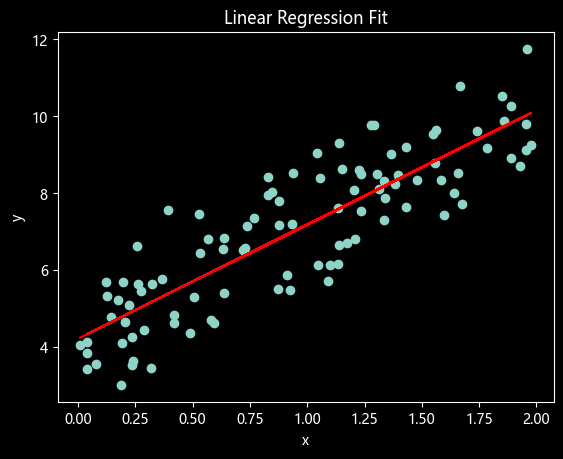

In [16]:
# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

# 创建线性回归模型
model = LinearRegression()

# 拟合模型
model.fit(x, y)

# 输出模型的参数
print(f"斜率 (w): {model.coef_[0][0]}")
print(f"截距 (b): {model.intercept_[0]}")

# 预测
y_pred = model.predict(x)

# 可视化拟合结果
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.show()

In [17]:
# score() 方法来评估模型性能，返回 R^2 值。

# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

# 创建线性回归模型
model = LinearRegression()

# 拟合模型
model.fit(x, y)
# 计算模型得分
score = model.score(x, y)
print("模型得分:", score)

模型得分: 0.7469629925504755


手动实现的斜率 (w): 2.968467510701028
手动实现的截距 (b): 4.222151077447219


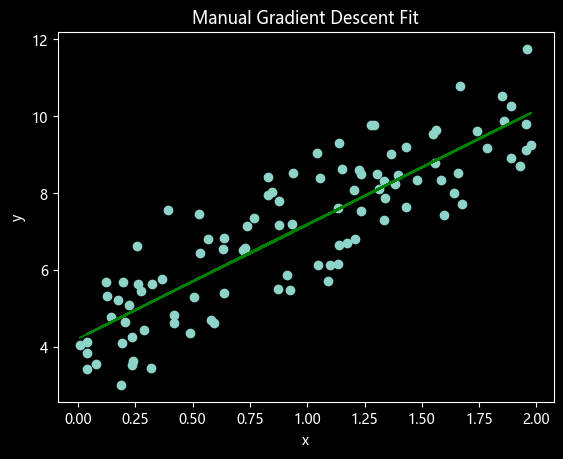

In [18]:
# 手动实现梯度下降法

# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

# 初始化参数
w = 0
b = 0
learning_rate = 0.1
n_iterations = 1000

# 梯度下降
for i in range(n_iterations):
    y_pred = w * x + b
    dw = -(2/len(x)) * np.sum(x * (y - y_pred))
    db = -(2/len(x)) * np.sum(y - y_pred)
    w = w - learning_rate * dw
    b = b - learning_rate * db

# 输出最终参数
print(f"手动实现的斜率 (w): {w}")
print(f"手动实现的截距 (b): {b}")

# 可视化手动实现的拟合结果
y_pred_manual = w * x + b
plt.scatter(x, y)
plt.plot(x, y_pred_manual, color='green')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Manual Gradient Descent Fit')
plt.show()

多元线性回归  
1. 核心概念  
多元线性回归是一种用于建立多个自变量（也叫特征、解释变量）与一个连续型因变量（也叫目标、响应变量）之间线性关系的统计方法。  
2. 模型公式  
多元线性回归模型的数学表达式如下：  
y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ + ε
其中：
y:因变量,我们想要预测的目标值（如：房价）。  
x₁, x₂, ..., xₙ:自变量,用于预测 y 的特征（如：面积、卧室数、房龄）。  
β₀:截距项,当所有自变量都为 0 时，y 的预测基准值。  
β₁, β₂, ..., βₙ:回归系数,每个自变量 xᵢ 的权重。它表示：在其他特征不变的情况下，xᵢ 每增加 1 个单位，y 平均变化 βᵢ 个单位。这是多元回归分析的核心。  
ε:误差项,模型无法解释的随机波动（如：测量误差、未知因素）。  

In [28]:
# 加载加州房价数据集
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target # 添加目标列：房屋中位数价格

print("数据集形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n特征说明:")
print(california.DESCR[:500]) # 打印部分描述

# 查看数据基本信息
print(df.info())
print("\n基本统计描述:")
print(df.describe())

# 划分特征(X)和目标(y)
X = df.drop('MedHouseVal', axis=1) # 特征矩阵：包含除目标外的所有列
y = df['MedHouseVal'] # 目标向量

# 划分训练集和测试集（70%训练，30%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"\n训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}")

数据集形状: (20640, 9)

前5行数据:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

特征说明:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block gro

In [31]:
# 创建、训练与评估模型
 
# 1. 创建模型实例
model = LinearRegression()

# 2. 训练模型（拟合数据）
model.fit(X_train, y_train)

# 3. 使用训练好的模型进行预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 4. 评估模型性能
# 均方误差 (MSE) - 越小越好
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# 决定系数 (R²) - 越接近1越好，表示模型解释力越强
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=== 模型性能评估 ===")
print(f"训练集 MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"测试集 MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 5. 查看学到的模型参数
print("\n=== 模型参数 ===")
print(f"截距 (β₀): {model.intercept_:.4f}")
print("回归系数 (β₁, β₂, ...):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

=== 模型性能评估 ===
训练集 MSE: 0.5234, R²: 0.6093
测试集 MSE: 0.5306, R²: 0.5958

=== 模型参数 ===
截距 (β₀): -37.0562
回归系数 (β₁, β₂, ...):
  MedInc: 0.4458
  HouseAge: 0.0097
  AveRooms: -0.1221
  AveBedrms: 0.7786
  Population: -0.0000
  AveOccup: -0.0034
  Latitude: -0.4185
  Longitude: -0.4337


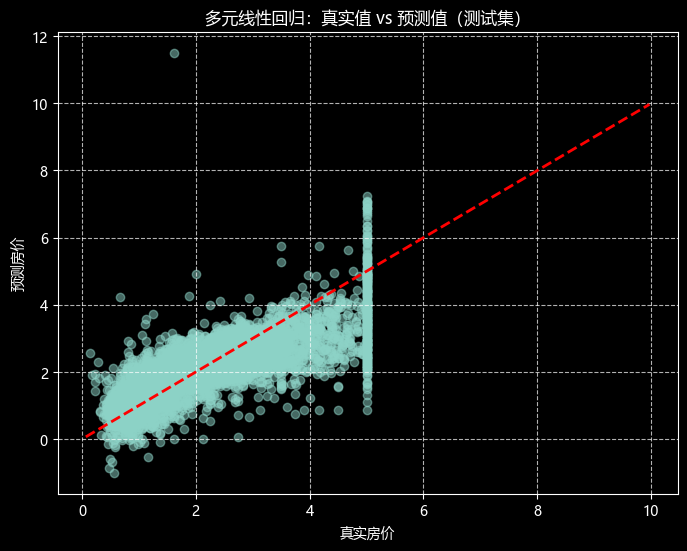

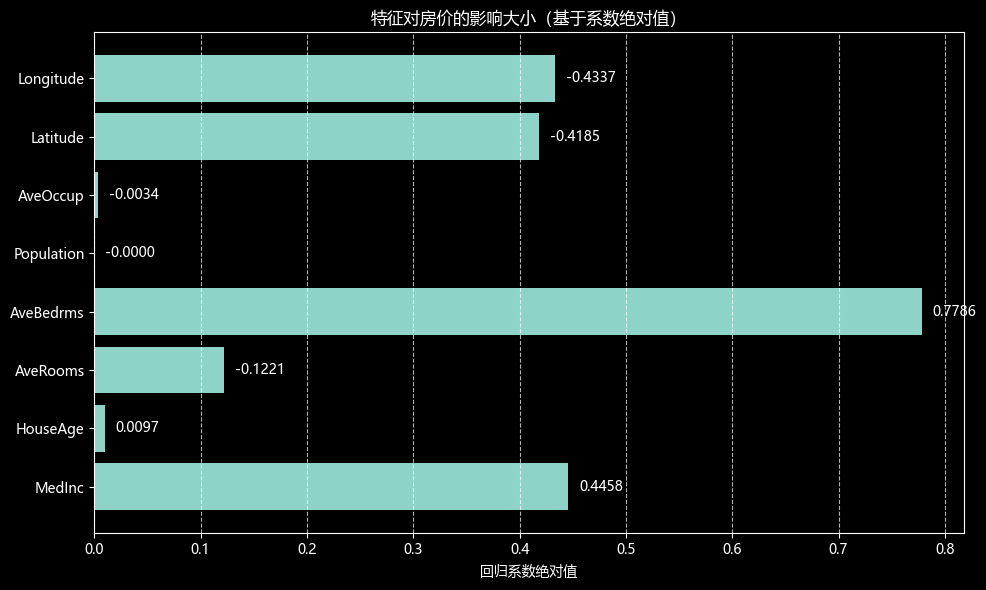

In [38]:
# 解读结果与可视化

# 可视化：真实值 vs 预测值 (测试集)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 绘制理想对角线
plt.xlabel('真实房价')
plt.ylabel('预测房价')
plt.title('多元线性回归：真实值 vs 预测值（测试集）')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 可视化：特征重要性（通过系数绝对值大小近似表示）
features = X_train.columns
coefs = model.coef_
plt.figure(figsize=(10, 6))
bars = plt.barh(features, np.abs(coefs)) # 使用绝对值比较影响大小
plt.xlabel('回归系数绝对值')
plt.title('特征对房价的影响大小（基于系数绝对值）')
# 为条形图添加数值标签
for bar, coef in zip(bars, coefs):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{coef:.4f}', va='center')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

多项式回归  
1. 核心概念  
多项式回归是线性回归的一种扩展。它通过为原始特征添加高次项（如平方项、立方项），将数据映射到更高维度的空间，从而用一条"曲线"来拟合数据中存在的非线性关系。 
2. 核心思想：  
将特征的高次幂视为新的特征，然后在这个扩展后的特征集上应用线性回归。  
例如，一个二次多项式回归模型： y = w₁ * x + w₂ * x² + b  
3. 关键术语   
阶数/次数：多项式中最高的指数。阶数为 2 是二次曲线（抛物线），阶数为 3 是三次曲线，以此类推。  
过拟合：如果选择的阶数太高，模型会变得非常"曲折"，完美穿过所有训练数据点，但对新数据的预测能力会急剧下降。就像用一张复杂的网去捕捉几个点，网眼太细，反而抓不住大鱼。  
欠拟合：如果阶数太低（比如用直线去拟合明显弯曲的数据），模型无法捕捉数据中的基本模式，预测能力同样很差。  


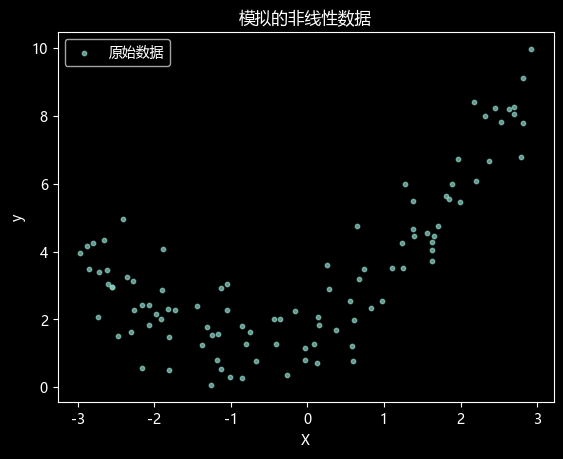

In [33]:
# 设置随机种子，确保每次运行结果一致
np.random.seed(42)

# 创建模拟数据：y 是 x 的二次函数加上一些随机噪声
X = 6 * np.random.rand(100, 1) - 3  # 生成100个在[-3, 3)区间的随机数
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)  # y = 0.5x² + x + 2 + 噪声

# 可视化原始数据
plt.scatter(X, y, s=10, alpha=0.7, label='原始数据')
plt.xlabel('X')
plt.ylabel('y')
plt.title('模拟的非线性数据')
plt.legend()
plt.show()

In [34]:
# 特征转换与模型训练

# 1. 创建多项式特征
# 参数 degree 决定了多项式的阶数，这里我们尝试2阶
poly_features = PolynomialFeatures(degree=2, include_bias=False)
# 将原始特征X转换为包含X和X^2的新特征矩阵X_poly
X_poly = poly_features.fit_transform(X)

print(f"原始X的形状: {X.shape}")
print(f"转换后X_poly的形状: {X_poly.shape}")
print(f"前5行X_poly数据:\n{X_poly[:5]}")
# 输出显示，X_poly 有两列：第一列是X，第二列是X^2

# 2. 在转换后的特征上训练线性回归模型
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)  # 使用X_poly，而不是原始的X

# 3. 查看学到的模型参数（权重和偏置）
print(f"\n模型参数（权重w1, w2）: {lin_reg.coef_.ravel()}")
print(f"模型偏置（截距b）: {lin_reg.intercept_}")
# 输出结果应接近我们生成数据时用的参数 [1, 0.5] 和 2

原始X的形状: (100, 1)
转换后X_poly的形状: (100, 2)
前5行X_poly数据:
[[-0.75275929  0.56664654]
 [ 2.70428584  7.3131619 ]
 [ 1.39196365  1.93756281]
 [ 0.59195091  0.35040587]
 [-2.06388816  4.25963433]]

模型参数（权重w1, w2）: [0.93366893 0.56456263]
模型偏置（截距b）: [1.78134581]


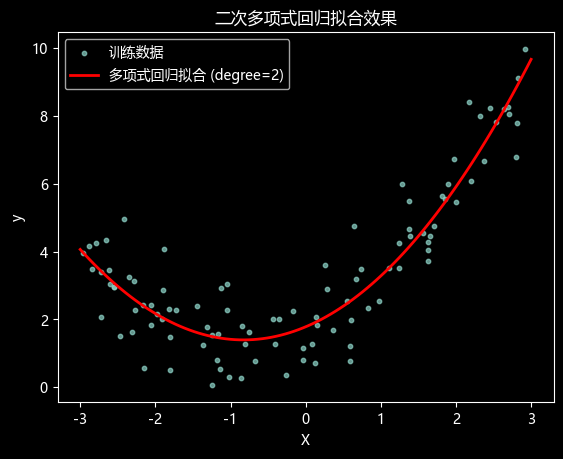

In [35]:
# 可视化欠拟合结果

# 为了画出平滑的曲线，需要生成一组均匀分布的点
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
# 对这组新点同样进行多项式特征转换
X_new_poly = poly_features.transform(X_new)
# 用模型进行预测
y_new = lin_reg.predict(X_new_poly)

# 开始绘图
plt.scatter(X, y, s=10, alpha=0.7, label='训练数据')
plt.plot(X_new, y_new, 'r-', linewidth=2, label='多项式回归拟合 (degree=2)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('二次多项式回归拟合效果')
plt.legend()
plt.show()

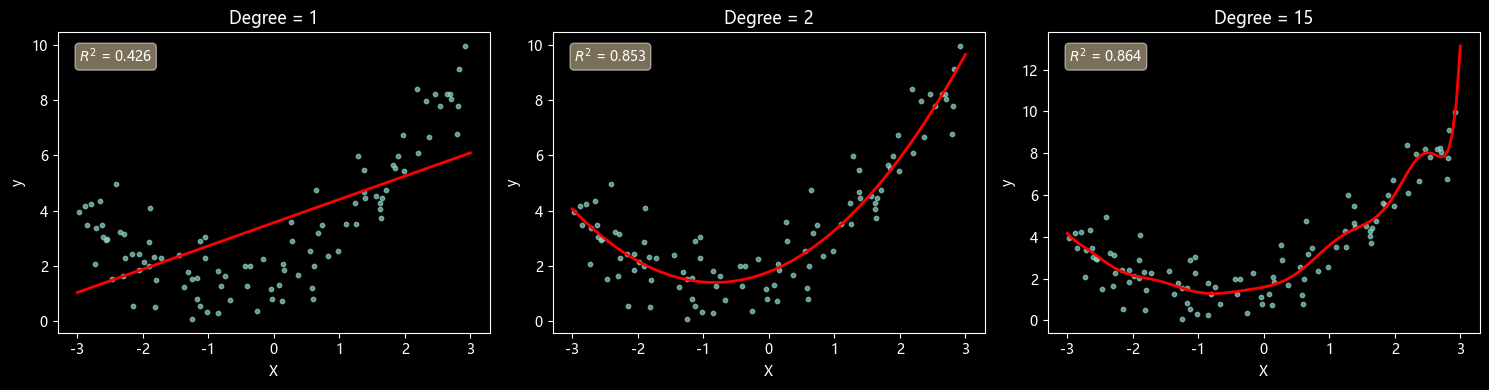

In [ ]:
# 选择合适的阶数

# 尝试不同的阶数：1（线性）， 2， 15（过高）
degrees = [1, 2, 15]
plt.figure(figsize=(15, 4))

for i, degree in enumerate(degrees):
    # 创建子图
    ax = plt.subplot(1, len(degrees), i + 1)
    
    # 生成多项式特征并训练模型
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y)
    
    # 预测并绘图
    y_new = lin_reg.predict(poly_features.transform(X_new))
    
    ax.scatter(X, y, s=10, alpha=0.7)
    ax.plot(X_new, y_new, 'r-', linewidth=2)
    ax.set_title(f'Degree = {degree}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    # 计算并显示R²分数（越接近1越好）
    y_pred = lin_reg.predict(X_poly)
    r2 = r2_score(y, y_pred)
    ax.text(0.05, 0.95, f'$R^2$ = {r2:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
"""
解释:
Degree=1（线性）：一条直线，R² 分数较低，明显欠拟合，无法表达数据的弯曲。
Degree=2（二次）：一条平滑的曲线，R² 分数很高，拟合效果很好。
Degree=15（十五次）：曲线剧烈震荡，穿过了很多数据点，但对数据点之间的趋势预测怪异。
它在训练数据上 R² 可能接近 1，但对新数据的预测会非常差，这就是典型的过拟合。
"""

根据交叉验证，最佳阶数是: 2


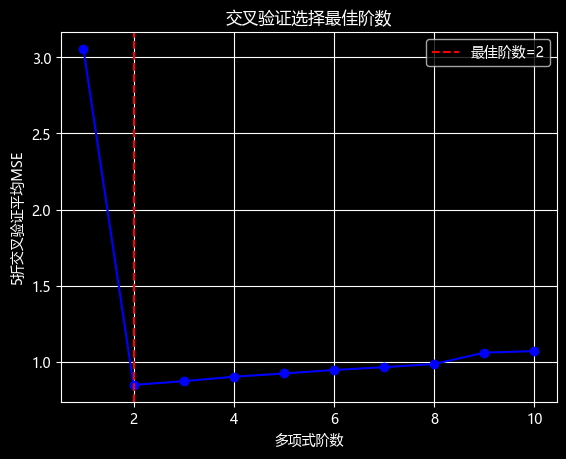

In [39]:
# 更科学的方法：交叉验证 —— scikit-learn 的 cross_val_score

# 测试一系列阶数
degrees_to_try = range(1, 11)
cv_scores = []

for degree in degrees_to_try:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    lin_reg = LinearRegression()
    # 使用5折交叉验证，以负均方误差作为评分（sklearn约定：分数越高越好，所以用负MSE）
    scores = cross_val_score(lin_reg, X_poly, y, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # 取平均并转回正数MSE

# 找到使交叉验证误差最小的阶数
best_degree = degrees_to_try[np.argmin(cv_scores)]
print(f"根据交叉验证，最佳阶数是: {best_degree}")

# 可视化交叉验证误差随阶数的变化
plt.plot(degrees_to_try, cv_scores, 'bo-')
plt.xlabel('多项式阶数')
plt.ylabel('5折交叉验证平均MSE')
plt.title('交叉验证选择最佳阶数')
plt.axvline(x=best_degree, color='r', linestyle='--', label=f'最佳阶数={best_degree}')
plt.legend()
plt.grid(True)
plt.show()

逻辑回归（Logistic Regression）  
1. 核心概念  
逻辑回归（Logistic Regression）是一种广泛应用于分类问题的统计学习方法，尽管名字中带有"回归"，但它实际上是一种用于二分类或多分类问题的算法。     
逻辑回归通过使用逻辑函数（也称为 Sigmoid 函数）将线性回归的输出映射到 0 和 1 之间，从而预测某个事件发生的概率。  
2. 应用场景：
垃圾邮件检测（是垃圾邮件/不是垃圾邮件）  
疾病预测（患病/不患病）  
客户流失预测（流失/不流失）  
逻辑回归的输出是一个概率值，表示样本属于某一类别的概率。  


In [45]:
# 加载数据集 —— Iris 数据集包含 150 个样本，每个样本有 4 个特征，目标是将样本分为 3 类。
# 为简化问题，我们只使用前两个特征，并将问题转化为二分类问题。

iris = load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = (iris.target != 0) * 1  # 将目标转化为二分类问题

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# 创建逻辑回归模型
model = LogisticRegression()

# 训练模型
model.fit(X_train, y_train)

# 预测测试集
y_pred = model.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)
print("混淆矩阵:")
print(conf_matrix)

# 分类报告
class_report = classification_report(y_test, y_pred)
print("分类报告:")
print(class_report)

模型准确率: 1.00
混淆矩阵:
[[19  0]
 [ 0 26]]
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        26

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



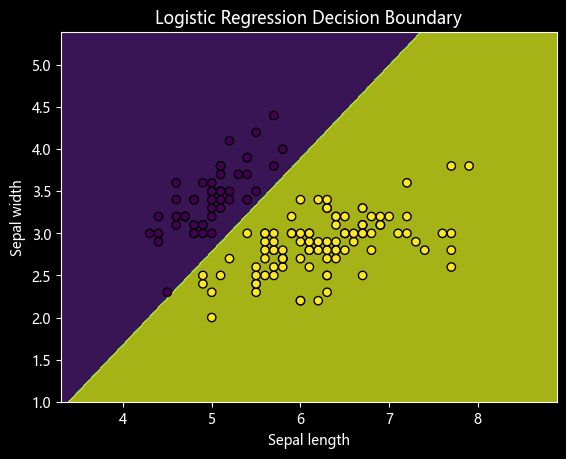

In [ ]:
# 可视化决策边界

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Logistic Regression Decision Boundary')
plt.show()

回归模型评估  
1. 平均绝对误差（MAE）  
理解：把所有预测"误差"的绝对值加起来，然后算个平均数。它直接反映了"平均来看，预测值大概偏离真实值多少单位"  
计算公式： MAE = (1/n) * Σ|y_i - ŷ_i|  
其中: n 是样本数量，Σ 是求和符号。 

特点：  
优点：直观易懂，不受极端误差值（异常值）的过度影响。  
缺点：绝对值函数在数学上不是处处可导，这在某些优化场景中不太方便。  
2. 均方误差（MSE）  
理解：先把每个误差"平方"一下（让负号消失并放大误差），然后求平均值。它对大的误差非常敏感。  
计算公式： MSE = (1/n) * Σ(y_i - ŷ_i)^2  

特点：  
优点：数学性质优秀（处处可导），是许多模型（如线性回归）训练时最小化的目标函数。  
缺点：量纲与原始数据不同，数值大小不易解释；对异常值敏感。  
3. 均方根误差（RMSE）
理解：就是MSE的平方根。相当于把MSE"打回原形"，让它和真实值、预测值回到同一个量纲上。  
计算公式： RMSE = sqrt(MSE)  

特点：  
优点：具有和原始数据相同的量纲，解释性比MSE强；对大误差惩罚更重，在重视大误差的场景（如金融风险预测）中很常用。  
缺点：同样对异常值敏感。  
4. R² 分数（决定系数）  
理解：我的模型，比"瞎猜"（用平均值猜）强多少？它是一个比例值，衡量模型对数据变化的解释能力。  
计算公式： R² = 1 - (Σ(y_i - ŷ_i)^2 / Σ(y_i - y_mean)^2)   
其中:y_mean 是真实值的平均值。

特点：  
范围：理论上，R² 的范围是 (-∞, 1]。  
R² = 1：完美预测。  
R² = 0：模型和直接用平均值预测的效果一样。  
R² < 0：模型比直接用平均值预测还要差（说明模型完全不适合数据）。  
优点：无量纲，易于比较不同数据集上的模型性能。  
缺点：随着模型特征增加，R² 会自然增大，即使增加的特征没有用，这可能导致过拟合。  

对比与选择

MAE:平均绝对误差,量纲与y相同，对异常值不敏感。解释最直观，关注"平均偏差多大"，适用于所有回归场景，尤其是异常值较多的数据。  
MSE：平均平方误差，量纲y的平方，对异常值非常敏感。数学性质好，是模型训练的常用损失函数。数值本身不易解释。  
RMSE：MSE的平方根，量纲与y相同，对异常值非常敏感。最常用，兼具MSE的数学优点和可解释性。对大误差惩罚重，在金融、预测等领域很受欢迎。  
R²：1 - (模型误差/基线误差)，无量纲，对异常值敏感。相对性能指标，用于比较模型相对于简单基准的提升程度。易于跨数据集比较。

选择建议：  
1).首选报告 RMSE 和 R²：RMSE 给出误差的实际大小，R² 给出模型的相对性能。这是最通用的组合。  
2).当数据中有许多异常值时，关注 MAE。  
3).在模型训练和优化阶段，使用 MSE 作为损失函数。  
4).永远不要只看一个指标！结合多个指标才能全面评估模型。  

=== 回归模型评估报告 ===
平均绝对误差 (MAE): 0.5913
均方误差 (MSE): 0.6537
均方根误差 (RMSE): 0.8085
决定系数 (R² Score): 0.8072

模型系数：
   截距 (Intercept): 4.1429
   斜率 (Coefficient for X): 2.7993


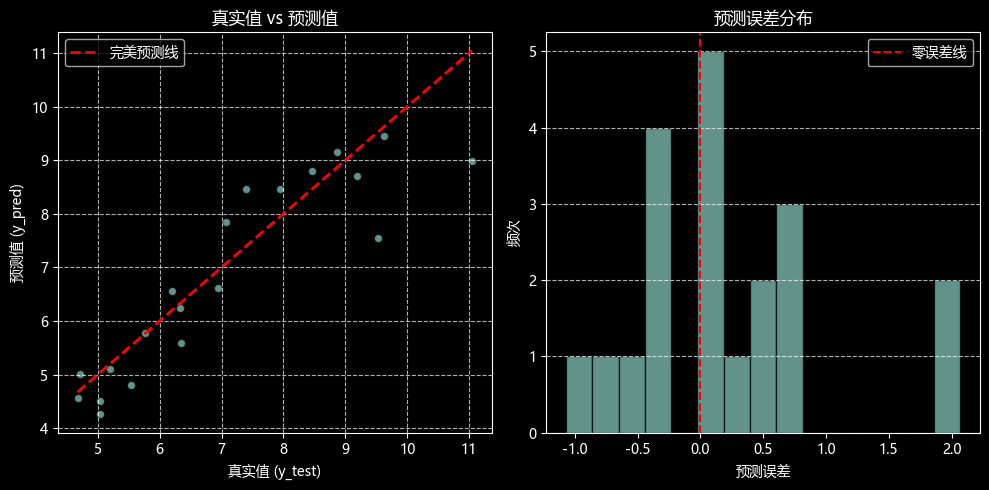

'\n代码逐行解析:\n创建数据：我们模拟了 y = 4 + 3x + 噪声 的数据，这是典型的线性关系加随机扰动。\n划分数据集：train_test_split 将数据随机分成两部分。用训练集 (X_train, y_train) 来学习模型，用从未见过的测试集 (X_test, y_test) 来评估其泛化能力。这是评估的关键一步！\n训练模型：创建 LinearRegression 对象并调用 .fit() 方法进行训练。\n进行预测：调用 .predict() 方法对测试集特征 X_test 生成预测值 y_pred。\n计算指标：使用 Scikit-learn 的 metrics 模块中的函数，轻松计算出 MAE, MSE, R²。RMSE 通过对 MSE 开方得到。\n打印结果：格式化输出所有指标和模型学到的参数。\n可视化：\n左图：理想情况下，散点应紧密围绕红色虚线（完美预测线）分布。\n右图：误差分布直方图应大致以0为中心呈正态分布，这通常是一个好迹象。\n'

In [49]:
# 1. 创建模拟数据
np.random.seed(42) # 确保每次运行结果一致
X = 2 * np.random.rand(100, 1) # 100个样本，1个特征，范围[0,2)
y = 4 + 3 * X + np.random.randn(100, 1) # 真实关系：y = 4 + 3x + 噪声

# 2. 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 训练一个简单的线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 在测试集上进行预测
y_pred = model.predict(X_test)

# 5. 计算所有评估指标
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # 或者用 mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# 6. 打印评估结果
print("=== 回归模型评估报告 ===")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"决定系数 (R² Score): {r2:.4f}")
print("\n模型系数：")
print(f"   截距 (Intercept): {model.intercept_[0]:.4f}")
print(f"   斜率 (Coefficient for X): {model.coef_[0][0]:.4f}")

# 7. 可视化结果
plt.figure(figsize=(10, 5))

# 子图1：真实值 vs 预测值散点图
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='完美预测线')
plt.xlabel('真实值 (y_test)')
plt.ylabel('预测值 (y_pred)')
plt.title('真实值 vs 预测值')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 子图2：误差分布直方图
plt.subplot(1, 2, 2)
errors = y_test.flatten() - y_pred.flatten()
plt.hist(errors, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', label='零误差线')
plt.xlabel('预测误差')
plt.ylabel('频次')
plt.title('预测误差分布')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7, axis='y')

plt.tight_layout()
plt.show()
"""
代码逐行解析:
创建数据：我们模拟了 y = 4 + 3x + 噪声 的数据，这是典型的线性关系加随机扰动。
划分数据集：train_test_split 将数据随机分成两部分。用训练集 (X_train, y_train) 来学习模型，用从未见过的测试集 (X_test, y_test) 来评估其泛化能力。这是评估的关键一步！
训练模型：创建 LinearRegression 对象并调用 .fit() 方法进行训练。
进行预测：调用 .predict() 方法对测试集特征 X_test 生成预测值 y_pred。
计算指标：使用 Scikit-learn 的 metrics 模块中的函数，轻松计算出 MAE, MSE, R²。RMSE 通过对 MSE 开方得到。
打印结果：格式化输出所有指标和模型学到的参数。
可视化：
左图：理想情况下，散点应紧密围绕红色虚线（完美预测线）分布。
右图：误差分布直方图应大致以0为中心呈正态分布，这通常是一个好迹象。
"""

决策树（Decision Tree）  
1. 决策树的基本概念  
决策树（Decision Tree）是一种常用的机器学习算法，广泛应用于分类和回归问题。   
决策树通过树状结构来表示决策过程，每个内部节点代表一个特征或属性的测试，每个分支代表测试的结果，每个叶节点代表一个类别或值。  
节点（Node）：树中的每个点称为节点。根节点是树的起点，内部节点是决策点，叶节点是最终的决策结果。  
分支（Branch）：从一个节点到另一个节点的路径称为分支。  
分裂（Split）：根据某个特征将数据集分成多个子集的过程。  
纯度（Purity）：衡量一个子集中样本的类别是否一致。纯度越高，说明子集中的样本越相似。  
2. 决策树的工作原理  
决策树通过递归地将数据集分割成更小的子集来构建树结构。具体步骤如下：  
1)选择最佳特征：根据某种标准（如信息增益、基尼指数等）选择最佳特征进行分割。  
2)分割数据集：根据选定的特征将数据集分成多个子集。  
3)递归构建子树：对每个子集重复上述过程，直到满足停止条件（如所有样本属于同一类别、达到最大深度等）。  
4)生成叶节点：当满足停止条件时，生成叶节点并赋予类别或值。  
3. 优缺点  
优点:  
1)易于理解和解释：决策树的结构直观，易于理解和解释。  
2)处理多种数据类型：可以处理数值型和类别型数据。   
3)不需要数据标准化：决策树不需要对数据进行标准化或归一化处理。   
缺点 ;  
1)容易过拟合：决策树容易过拟合，特别是在数据集较小或树深度较大时。  
2)对噪声敏感：决策树对噪声数据较为敏感，可能导致模型性能下降。  
3)不稳定：数据的小变化可能导致生成完全不同的树。  

In [52]:
# 加载鸢尾花数据集
iris = load_iris()
X = iris.data
y = iris.target

# 将数据集分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建决策树分类器
clf = DecisionTreeClassifier()

# 训练模型
clf.fit(X_train, y_train)

# 对测试集进行预测
y_pred = clf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

模型准确率: 1.00


支持向量机  
1. 核心思想
支持向量机（Support Vector Machine，简称 SVM）是一种监督学习算法，主要用于分类和回归问题。  
SVM 的核心思想是找到一个最优的超平面，将不同类别的数据分开。这个超平面不仅要能够正确分类数据，还要使得两个类别之间的间隔（margin）最大化。  
2. 核心概念
超平面：  
在二维空间中，超平面是一个直线。  
在三维空间中，超平面是一个平面。  
在更高维空间中，超平面是一个分割空间的超平面。  
支持向量：  
支持向量是离超平面最近的样本点。这些支持向量对于定义超平面至关重要。  
支持向量机通过最大化支持向量到超平面的距离（即最大化间隔）来选择最佳的超平面。  
最大间隔：  
SVM的目标是最大化分类间隔，使得分类边界尽可能远离两类数据点。这可以有效地减少模型的泛化误差。  
核技巧（Kernel Trick）：  
对于非线性可分的数据，SVM使用核函数将数据映射到更高维的空间，在这个空间中，数据可能是线性可分的。  
常用的核函数有：线性核、多项式核、径向基函数（RBF）核等。  
3. SVM 分类流程  
选择一个超平面：找到一个能够最大化分类边界的超平面。  
训练支持向量：通过支持向量机算法，选择离超平面最近的样本点作为支持向量。  
通过最大化间隔来找到最优超平面：选择一个最优超平面，使得间隔最大化。  
使用核函数处理非线性问题：通过核函数将数据映射到高维空间来解决非线性可分问题。  

模型准确率: 0.80
模型准确率: 0.80


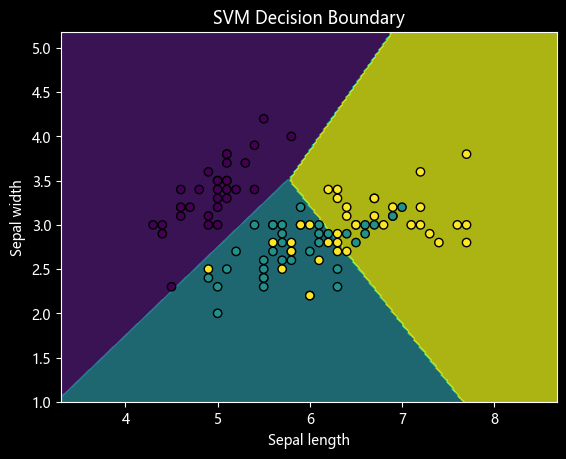

In [57]:
# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = iris.target

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建SVM分类器
clf = svm.SVC(kernel='linear')  # 使用线性核函数

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只使用前两个特征
y = iris.target

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建SVM分类器
clf = svm.SVC(kernel='linear')  # 使用线性核函数

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")

# 绘制决策边界
def plot_decision_boundary(X, y, model):
    h = .02  # 网格步长
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('SVM Decision Boundary')
    plt.show()

plot_decision_boundary(X_train, y_train, clf)

K 近邻算法

K 近邻算法（K-Nearest Neighbors，简称 KNN）是一种简单且常用的分类和回归算法。  
K 近邻算法属于监督学习的一种，核心思想是通过计算待分类样本与训练集中各个样本的距离，找到距离最近的 K 个样本，然后根据这 K 个样本的类别或值来预测待分类样本的类别或值。

1. 基本原理  
KNN 算法的基本原理可以概括为以下几个步骤：  
计算距离：计算待分类样本与训练集中每个样本的距离。常用的距离度量方法有欧氏距离、曼哈顿距离等。  
选择 K 个最近邻：根据计算出的距离，选择距离最近的 K 个样本。  
投票或平均：对于分类问题，K 个最近邻中出现次数最多的类别即为待分类样本的类别；对于回归问题，K 个最近邻的值的平均值即为待分类样本的值。  
2. 特点  
简单易理解：KNN 算法的原理非常简单，容易理解和实现。  
无需训练：KNN 是一种"懒惰学习"算法，不需要显式的训练过程，所有的计算都在预测时进行。  
对数据分布无假设：KNN 不对数据的分布做任何假设，适用于各种类型的数据。  
计算复杂度高：由于 KNN 需要在预测时计算所有样本的距离，当数据集较大时，计算复杂度会很高。  
3. 优缺点
优点：  
简单易用：KNN 算法的原理简单，易于理解和实现。  
无需训练：KNN 不需要显式的训练过程，所有的计算都在预测时进行。  
适用于多分类问题：KNN 可以轻松处理多分类问题。  
缺点：   
计算复杂度高：KNN 需要在预测时计算所有样本的距离，当数据集较大时，计算复杂度会很高。  
对噪声敏感：KNN 对噪声数据较为敏感，噪声数据可能会影响预测结果。  
需要选择合适的 K 值：K 值的选择对模型的性能有很大影响，选择合适的 K 值是一个挑战。  

KNN模型的准确率: 0.7556
KNN模型的准确率: 0.7556


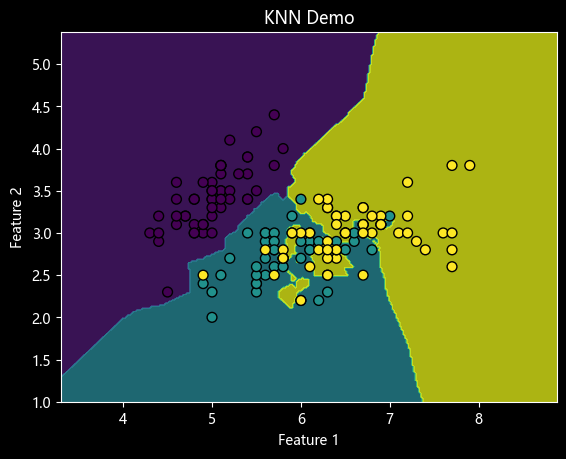

In [63]:
# 加载Iris数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只取前两个特征，便于可视化
y = iris.target

# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN模型，设置K值为3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN模型的准确率: {accuracy:.4f}")

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 加载Iris数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只取前两个特征，便于可视化
y = iris.target

# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN模型，设置K值为3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN模型的准确率: {accuracy:.4f}")

# 绘制决策边界和数据点
h = .02  # 网格步长
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 创建一个二维网格，表示不同的样本空间
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 使用KNN模型预测网格中的每个点的类别
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.contourf(xx, yy, Z, alpha=0.8)

# 绘制训练数据点
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50)
plt.title("KNN Demo")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

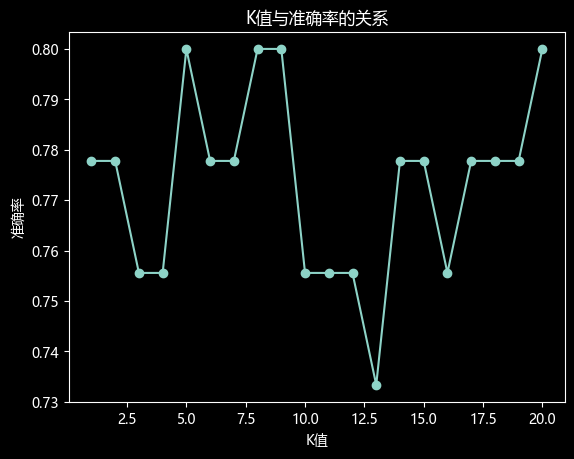

In [64]:
# 尝试不同的K值并绘制准确率变化
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# 绘制K值与准确率的关系
plt.plot(k_range, accuracies, marker='o')
plt.title("K值与准确率的关系")
plt.xlabel("K值")
plt.ylabel("准确率")
plt.show()

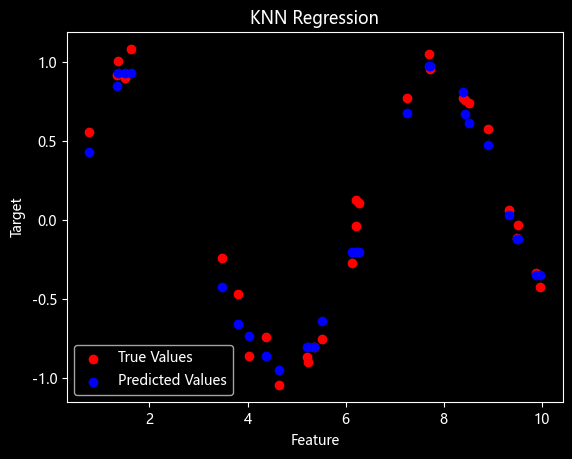

In [67]:
# 使用 KNN 进行回归任务
"""
KNN 同样可以用于回归任务（KNN Regression）。
在回归任务中，KNN 根据 K 个最近邻的目标值进行平均来预测输出。
"""

# 生成示例数据
X = np.random.rand(100, 1) * 10
y = np.sin(X).ravel() + 0.1 * np.random.randn(100)

# 拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建KNN回归模型
knn_reg = KNeighborsRegressor(n_neighbors=5)

# 训练模型
knn_reg.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = knn_reg.predict(X_test)

# 可视化回归结果
plt.scatter(X_test, y_test, color='red', label='True Values')
plt.scatter(X_test, y_pred, color='blue', label='Predicted Values')
plt.title("KNN Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()
# 红色为真实值，蓝色为预测值

随机森林  

1. 核心思想：Bagging 与随机性  
1)Bagging（Bootstrap Aggregating）：  
Bootstrap（自助采样）： 从原始训练数据集中有放回地随机抽取样本，生成多个不同的子训练集。这意味着同一个样本可能在一个子集中出现多次，而另一个样本可能一次都不出现。   
Aggregating（聚合）： 用每个子训练集独立训练一棵决策树，最后将所有树的结果聚合起来（投票或平均）。  
2)特征随机性：  
在构建每棵树的每个节点进行分裂时，算法不会考虑所有的特征，而是从全部特征中随机选取一个子集，然后从这个子集中选择最优分裂特征。这进一步增强了树与树之间的差异性，让森林看到问题的不同侧面。    
2. 关键超参数  
1)n_estimators:森林中决策树的数量。默认 100。值越大，模型通常越稳定，性能越好，但计算成本也越高。"委员会的人数"。人越多，决策通常越可靠，但开会时间也更长。  
2)max_depth:单棵决策树的最大深度。默认 None（不限制）。限制深度可以防止过拟合，使模型更简单。"限制每个人的发言时间"。防止某个专家（树）钻牛角尖，过度关注训练数据的细节。  
3)max_features:寻找最佳分裂时考虑的特征数。可以是整数、浮点数或 'auto'/'sqrt'。这是引入"特征随机性"的关键参数。"每次讨论只随机看几个方面"。确保每棵树从不同角度分析问题，增加多样性。  
4)min_samples_split:节点分裂所需的最小样本数。默认 2。值越大，树生长越保守，越不容易过拟合。"一个小组至少要有几个人才能继续分组讨论"。避免因为一两个样本就创建一个新规则。  
5)min_samples_leaf:叶节点所需的最小样本数。默认 1。值越大，模型越平滑。"最终结论至少需要基于几个案例"。确保每个结论都有一定的数据支撑。  
6)bootstrap:是否使用 Bootstrap 采样。默认 True。如果设为 False，则将使用整个数据集训练每棵树，但会失去一部分随机性。"是否允许一个人重复发言"。开启就是 Bagging 的精髓。  
3. 优缺点  
优点:  
1)高准确率： 集成学习通常能取得当前数据下顶尖的性能。  
2)抗过拟合能力强： 得益于 Bagging 和随机特征选择，即使不剪枝，也不容易过拟合。  
3)对数据要求友好： 能处理数值型和类别型特征，不需要特征缩放（如归一化）。  
4)提供特征重要性： 内置的特征评估是宝贵的副产品。  
5)并行化容易： 每棵树的训练是独立的，可以轻松并行加速。  
缺点:  
1)模型可解释性差： 成百上千棵树组成的"黑箱"，比单棵决策树难解释得多。  
2)训练和预测速度较慢： 树的数量多时，需要更多的计算资源和时间。  
3)内存占用大： 需要存储整个森林的所有树结构。  
4. 应用场景  
分类问题： 如垃圾邮件识别、疾病诊断、图像分类。  
回归问题： 如房价预测、销售额预测。   
特征选择： 利用其输出的特征重要性进行特征筛选。  
缺失值处理： 随机森林有较好的处理缺失值的天然能力。  

In [68]:
# 1）.基础分类任务

# 1. 加载数据
iris = load_iris()
X = iris.data  # 特征：花萼长度、宽度，花瓣长度、宽度
y = iris.target # 标签：三种鸢尾花

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 创建随机森林分类器
# 这里我们设置 100 棵树，并限制最大深度为 5
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 4. 训练模型
rf_clf.fit(X_train, y_train)

# 5. 在测试集上进行预测
y_pred = rf_clf.predict(X_test)

# 6. 评估模型性能
print("测试集准确率：", accuracy_score(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

测试集准确率： 1.0

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



测试集准确率： 1.0

分类报告：
特征重要性排序：
                  特征       重要性
3   petal width (cm)  0.436574
2  petal length (cm)  0.417326
0  sepal length (cm)  0.104614
1   sepal width (cm)  0.041486


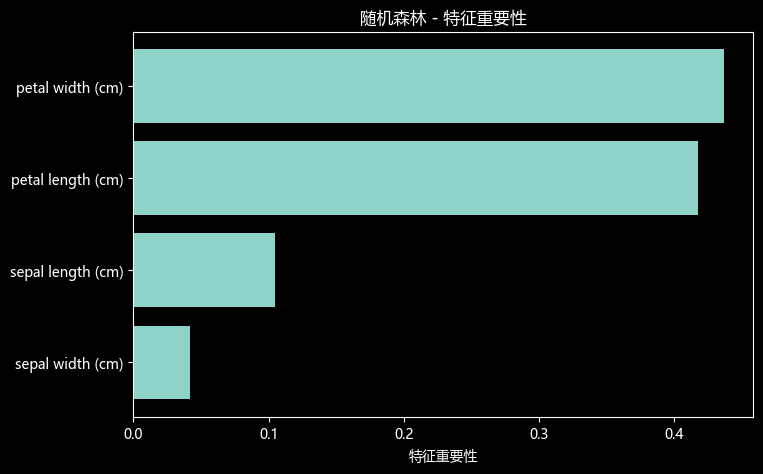

In [ ]:
# 2）查看特征重要性


# 1. 加载数据
iris = load_iris()
X = iris.data  # 特征：花萼长度、宽度，花瓣长度、宽度
y = iris.target # 标签：三种鸢尾花

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 创建随机森林分类器
# 这里我们设置 100 棵树，并限制最大深度为 5
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 4. 训练模型
rf_clf.fit(X_train, y_train)

# 5. 在测试集上进行预测
y_pred = rf_clf.predict(X_test)

# 6. 评估模型性能
print("测试集准确率：", accuracy_score(y_test, y_pred))
print("\n分类报告：")


# 获取特征重要性
feature_importances = rf_clf.feature_importances_
features = iris.feature_names

# 创建 DataFrame 便于查看
importance_df = pd.DataFrame({
    '特征': features,
    '重要性': feature_importances
}).sort_values('重要性', ascending=False)

print("特征重要性排序：")
print(importance_df)

# 可视化
plt.figure(figsize=(8, 5))
plt.barh(importance_df['特征'], importance_df['重要性'])
plt.xlabel('特征重要性')
plt.title('随机森林 - 特征重要性')
plt.gca().invert_yaxis() # 让最重要的特征显示在顶部
plt.show()
"""
你可能会发现花瓣长度和花瓣宽度的重要性远高于花萼的尺寸。
这非常符合植物学常识，花瓣特征确实是区分不同鸢尾花的关键。这个功能对于特征筛选和数据理解极具价值。
"""